# 🔍 Análise Exploratória de Dados sobre o Conjunto de Dados de Descrições de Trabalho

Neste notebook, realizamos uma análise exploratória abrangente em um conjunto de dados contendo mais de 1,6 milhão de descrições de trabalho. O objetivo é descobrir insights relacionados à experiência profissional, faixas salariais, locais de trabalho, funções, habilidades em demanda e padrões relacionados às empresas.

Os passos incluem:

- Compreender a estrutura do conjunto de dados
- Limpar os dadosDescobrir padrões usando visualizações
- Obter insights sobre negócios e contratações.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Carrega dataset
df = pd.read_csv("./jobs.csv")
df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


Dataset Overview

In [20]:
print("Shape of dataset:", df.shape) # Shape and Columns
df.columns

Shape of dataset: (25064, 24)


Index(['Job_Id', 'Experience', 'Qualifications', 'Salary_Range', 'location',
       'Country', 'latitude', 'longitude', 'Work_Type', 'Company_Size',
       'Job_Posting_Date', 'Preference', 'Contact_Person', 'Contact',
       'Job_Title', 'Role', 'Job_Portal', 'Job_Description', 'Benefits',
       'skills', 'Responsibilities', 'Company', 'Company_Profile',
       'Job_Category'],
      dtype='object')

In [4]:
df.describe() # Initial Descriptive Stats


,Job Id,latitude,longitude,Company Size
count,2.514600e+04,25146.000000,25146.000000,25146.000000
mean,1.552957e+15,19.080618,16.406157,73666.922970
std,8.963910e+14,23.447114,71.449218,35377.770341
min,2.018175e+11,-40.900600,-175.198200,12648.000000
25%,7.722071e+14,4.570900,-15.180400,42722.750000
50%,1.560093e+15,17.607800,19.374400,73705.000000
75%,2.325702e+15,38.969700,48.516400,104067.250000
max,3.099079e+15,71.706900,178.065000,134831.000000


In [5]:
df.info() # Info and Data Types


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25146 entries, 0 to 25145
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Job Id            25146 non-null  int64  
 1   Experience        25146 non-null  object 
 2   Qualifications    25146 non-null  object 
 3   Salary Range      25146 non-null  object 
 4   location          25146 non-null  object 
 5   Country           25146 non-null  object 
 6   latitude          25146 non-null  float64
 7   longitude         25146 non-null  float64
 8   Work Type         25146 non-null  object 
 9   Company Size      25146 non-null  int64  
 10  Job Posting Date  25146 non-null  object 
 11  Preference        25146 non-null  object 
 12  Contact Person    25146 non-null  object 
 13  Contact           25146 non-null  object 
 14  Job Title         25146 non-null  object 
 15  Role              25146 non-null  object 
 16  Job Portal        25146 non-null  object

In [6]:
# Renaming Columns
df.rename(columns={ 
    'Job Id': 'Job_Id',
    'Salary Range': 'Salary_Range',
    'Work Type': 'Work_Type',
    'Company Size': 'Company_Size',
    'Job Posting Date': 'Job_Posting_Date',
    'Contact Person': 'Contact_Person',
    'Job Title': 'Job_Title',
    'Job Portal': 'Job_Portal',
    'Job Description': 'Job_Description',
    'Company Profile': 'Company_Profile'
}, inplace=True)

In [7]:
df.isnull().sum() # Handling Null Values


Job_Id               0
Experience           0
Qualifications       0
Salary_Range         0
location             0
Country              0
latitude             0
longitude            0
Work_Type            0
Company_Size         0
Job_Posting_Date     0
Preference           0
Contact_Person       0
Contact              0
Job_Title            0
Role                 0
Job_Portal           0
Job_Description      0
Benefits             0
skills               0
Responsibilities     0
Company              0
Company_Profile     82
dtype: int64

In [8]:
df.dropna(inplace=True)
df.isnull().sum()

Job_Id              0
Experience          0
Qualifications      0
Salary_Range        0
location            0
Country             0
latitude            0
longitude           0
Work_Type           0
Company_Size        0
Job_Posting_Date    0
Preference          0
Contact_Person      0
Contact             0
Job_Title           0
Role                0
Job_Portal          0
Job_Description     0
Benefits            0
skills              0
Responsibilities    0
Company             0
Company_Profile     0
dtype: int64

In [9]:
# Removing Duplicates
df.drop_duplicates(inplace=True)


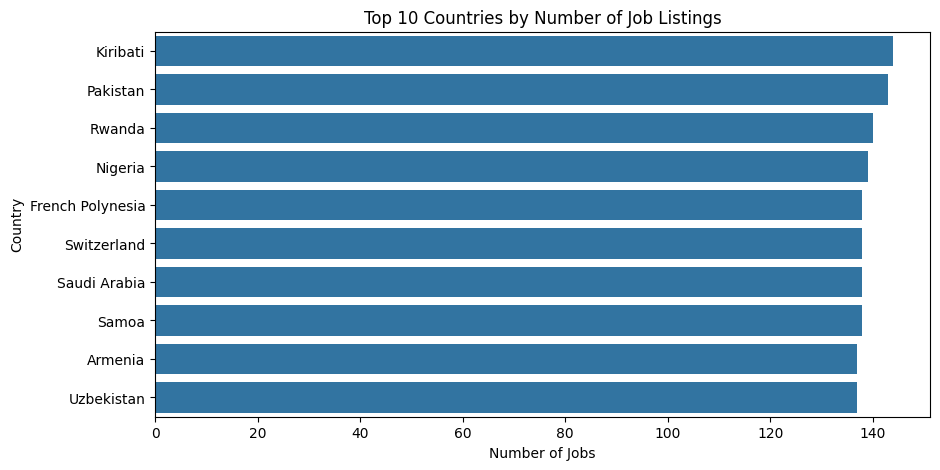

In [11]:
# Top 10 Countries by Job Listings
top_countries = df['Country'].value_counts().nlargest(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Number of Job Listings")
plt.xlabel("Number of Jobs")
plt.ylabel("Country")
plt.show()

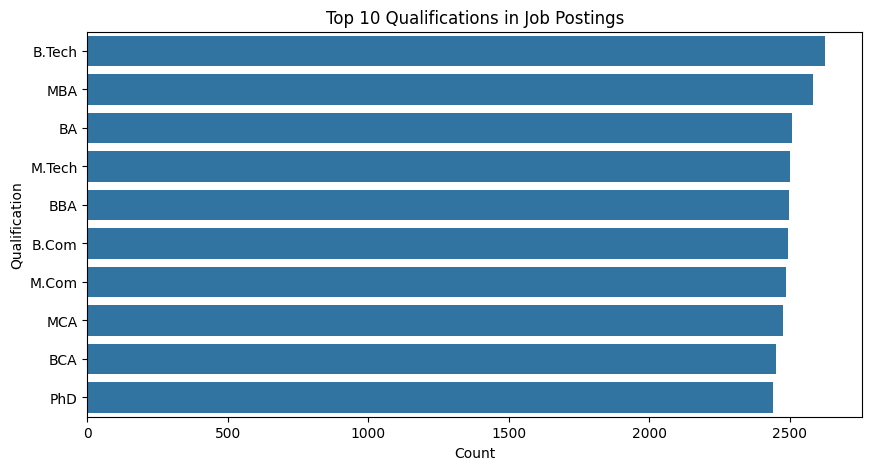

In [10]:
# Most Common Qualifications
plt.figure(figsize=(10,5))
sns.countplot(y='Qualifications', data=df, order=df['Qualifications'].value_counts().head(10).index)
plt.title("Top 10 Qualifications in Job Postings")
plt.xlabel("Count")
plt.ylabel("Qualification")
plt.show()

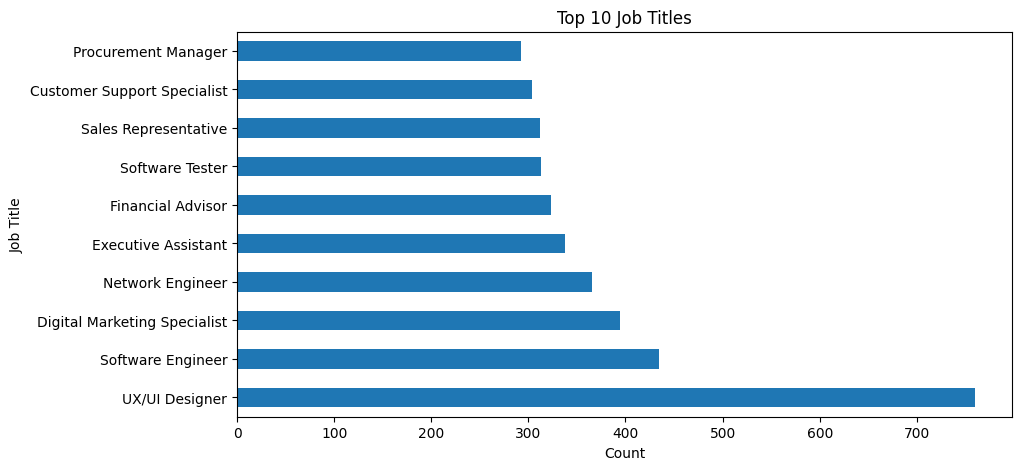

In [12]:
# Popular Job Titles
plt.figure(figsize=(10,5))
df['Job_Title'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Job Titles")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.show()

Group Job Titles into Categories¶


In [13]:
def categorize_job(title):
    title = str(title).lower()
    if 'software' in title or 'developer' in title or 'engineer' in title:
        return 'Technology'
    elif 'data' in title or 'analyst' in title:
        return 'Data & Analytics'
    elif 'marketing' in title or 'media' in title or 'brand' in title:
        return 'Marketing & Communications'
    elif 'nurse' in title or 'therapist' in title or 'practitioner' in title:
        return 'Healthcare'
    elif 'admin' in title or 'assistant' in title or 'coordinator' in title:
        return 'Administration'
    elif 'finance' in title or 'accountant' in title or 'banker' in title:
        return 'Finance'
    elif 'manager' in title or 'project' in title or 'operations' in title:
        return 'Management'
    elif 'support' in title or 'customer' in title or 'service' in title:
        return 'Customer Service'
    else:
        return 'Other'

df['Job_Category'] = df['Job_Title'].apply(categorize_job)


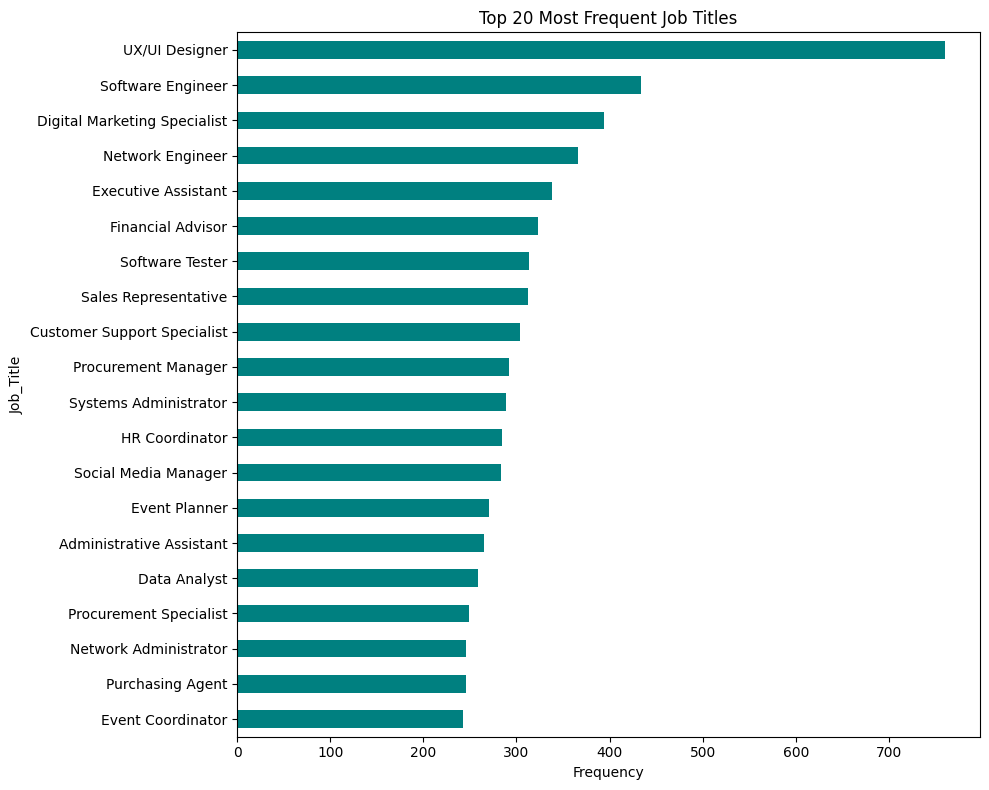

In [14]:
# Frequency Distribution Bar Plot
top_jobs = df['Job_Title'].value_counts().head(20)
plt.figure(figsize=(10, 8))
top_jobs.plot(kind='barh', color='teal')
plt.title('Top 20 Most Frequent Job Titles')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'yelp.csv'